#Grafica de estacionalidad sobre la temperatura de nayarit

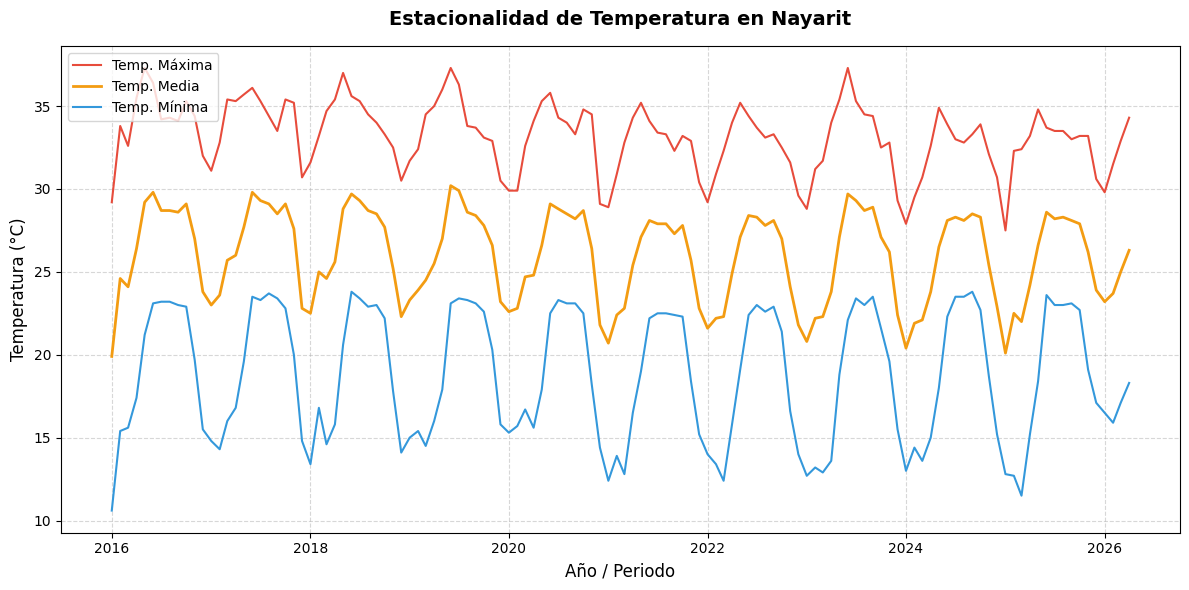

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

#Cargar los datos
df = pd.read_csv('/data_nayarit.csv')

#Convertir la columna PERIODO a formato datetime
#dayfirst=True porque las fechas vienen en formato DD/MM/YYYY
df['PERIODO'] = pd.to_datetime(df['PERIODO'], dayfirst=True)

#Ordenar los datos
df = df.sort_values('PERIODO')

#Configurar el tamaño de la gráfica
plt.figure(figsize=(12, 6))

#Graficar las líneas
plt.plot(df['PERIODO'], df['MAXIMA'], label='Temp. Máxima', color='#e74c3c', linewidth=1.5)
plt.plot(df['PERIODO'], df['MEDIA'], label='Temp. Media', color='#f39c12', linewidth=2)
plt.plot(df['PERIODO'], df['MINIMA'], label='Temp. Mínima', color='#3498db', linewidth=1.5)

#Personalizar
plt.title('Estacionalidad de Temperatura en Nayarit', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año / Periodo', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10)

#Ajustar el diseño
plt.tight_layout()
plt.show()

#Grafica de la calidad del aire de nayarit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv("/Nayarit_012.csv")

# Combinamos la fecha y la hora para tener un registro temporal exacto
df["fecha_completa"] = pd.to_datetime(
    df["fecha"] + " " + df["hora"].astype(str) + ":00:00", dayfirst=True)

#Filtrar por un contaminante para el análisis
contaminante = "Monoxido de carbono"
df_filtrado = df[df["nombre_contaminante"] == contaminante].copy()

#Agrupar por día para obtener el promedio diario y suavizar la gráfica
df_diario = (
    df_filtrado.groupby(df_filtrado["fecha_completa"].dt.date)["valor"]
    .mean()
    .reset_index()
)
df_diario["fecha_completa"] = pd.to_datetime(df_diario["fecha_completa"])

#Calcular la línea de tendencia)
x_numerico = df_diario["fecha_completa"].map(pd.Timestamp.toordinal)
y_valores = df_diario["valor"]

#Ajuste polinomial de grado 1 (línea recta: y = mx + b)
pendiente, interseccion = np.polyfit(x_numerico, y_valores, 1)
linea_tendencia = pendiente * x_numerico + interseccion

#Graficar
plt.figure(figsize=(12, 6))

#Dibujar los promedios diarios
plt.plot(
    df_diario["fecha_completa"],
    y_valores,
    label="Promedio Diario",
    color="steelblue",
    alpha=0.7,
)

#Dibujar la línea de tendencia
plt.plot(
    df_diario["fecha_completa"],
    linea_tendencia,
    label="Línea de Tendencia",
    color="crimson",
    linestyle="--",
    linewidth=2,
)

# Personalización de la gráfica
plt.title(
    f"Tendencia Temporal de {contaminante} (Tepic, Nayarit)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel(f"Concentración ({df_filtrado['unidades'].iloc[0]})", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Nayarit_012.csv'